In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [68]:
class Agent:
    def __init__(self, utility_function, cost_function, bundle, initial_wealth, vision, position):
        self.utility_function = utility_function
        self.cost_function = cost_function
        self.bundle = bundle
        self.utility = initial_wealth
        self.vision = vision
        self.position = position

    def move(self, environment):
        next_position = self.position
        next_utility = self.utility_function(environment.get_resource_at(next_position))
        for dx in range(-self.vision, self.vision + 1):
            for dy in range(-self.vision, self.vision + 1):
                potential_position = (self.position[0] + dx, self.position[1] + dy)
                if environment.is_valid_position(potential_position):
                    potential_utility = self.utility_function(environment.get_resource_at(potential_position))
                    if potential_utility > next_utility:
                        next_position = potential_position
                        next_utility = potential_utility
        self.position = next_position


In [46]:
def generate_landscape(height, width, resource_fn, max_resource=10):
    y, x = np.meshgrid(np.linspace(0, 1, height), np.linspace(0, 1, width), indexing='ij')
    z = np.clip(resource_fn(x, y), 0, None)
    return z / z.max() * max_resource if z.max() > 0 else z

class Environment:
    def __init__(self, height, width, resource_fn, max_resource=10):
        self.landscape = generate_landscape(height, width, resource_fn, max_resource)

    def is_valid_position(self, position):
        x, y = position
        return 0 <= x < self.landscape.shape[0] and 0 <= y < self.landscape.shape[1]

    def get_resource_at(self, position):
        return self.landscape[position]



In [69]:
def initialize(num_agents, environment_size, landscape_function, max_resource):
    env = Environment(environment_size[0], environment_size[1], landscape_function, max_resource)
    # Initialize agents with random positions and parameters
    agents = []
    for agent in range(num_agents):
        utility_fn = lambda resource: resource  # Simple utility function based on resource level
        cost_fn = lambda resource: 0.1 * resource  # Simple cost function
        bundle = None  # Placeholder for agent's bundle of goods
        vision = 3  # Vision range for movement
        position = (np.random.randint(0, env.landscape.shape[0]), np.random.randint(0, env.landscape.shape[1]))
        initial_wealth = 0 + env.get_resource_at(position)  # Initial wealth for each agent
        agents.append(Agent(utility_fn, cost_fn, bundle, initial_wealth, vision, position))
    return agents, env

In [83]:
def observe(agents, env):
    plt.imshow(env.landscape, cmap='viridis')
    plt.colorbar(label='Resource Level')
    utilities = [agent.utility_function(env.get_resource_at(agent.position)) for agent in agents]
    scatter = plt.scatter(
        [agent.position[1] for agent in agents],
        [agent.position[0] for agent in agents],
        c=utilities,
        cmap='plasma',
        edgecolors='black',
        label='Agents'
    )
    plt.colorbar(scatter, label='Agent Utility')
    plt.title('Environment Landscape')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()



In [57]:
def run(timesteps, num_agents, environment_size, landscape_function, max_resource):
    agents, env = initialize(num_agents, environment_size, landscape_function, max_resource)
    
    observe(agents, env)

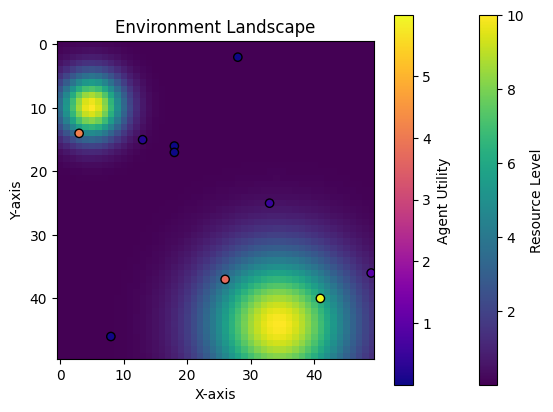

In [84]:
f = lambda x, y: np.exp(-((x - 0.1) ** 2 + (y - 0.2) ** 2)/.01) + np.exp(-((x - 0.7) ** 2 + (y - 0.9) ** 2)/.05)

run(timesteps=10, num_agents=10, environment_size=(50, 50), landscape_function=f, max_resource=10)